<a href="https://colab.research.google.com/github/GaneshUppananthala2005/Akash-6G-/blob/main/PREDICTION_OF_DATA_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AKASH-6G PHASE 1 — PHYSICAL LEO + BEAMFORMING
Records: 50,000 | UEs: 500 | samples/UE: 100
Orbit: 600 km | velocity: 7.5617 km/s
Angular rate: 0.0010847 rad/s | period: 96.54 min
Carrier: 2.185 GHz | wavelength: 0.1372 m
ULA: 8 elements, lambda/2 spacing | beams: [5.0, 20.0, 35.0, 50.0]


/tmp/ipykernel_512/2195944937.py:168: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  df["Current_Beam"]=df[rcols].idxmax(axis=1).str.extract(r"(\d)").astype("Int64")



Validation passed.
Visible records: 31630
Doppler range: -50.35 to 50.36 kHz
Elevation range: 5.00 to 46.30 deg
Best SINR range: -32.80 to -17.11 dB
Optimal beam (%):
Optimal_Beam_Label
2     0.98
3    99.02
Name: proportion, dtype: float64


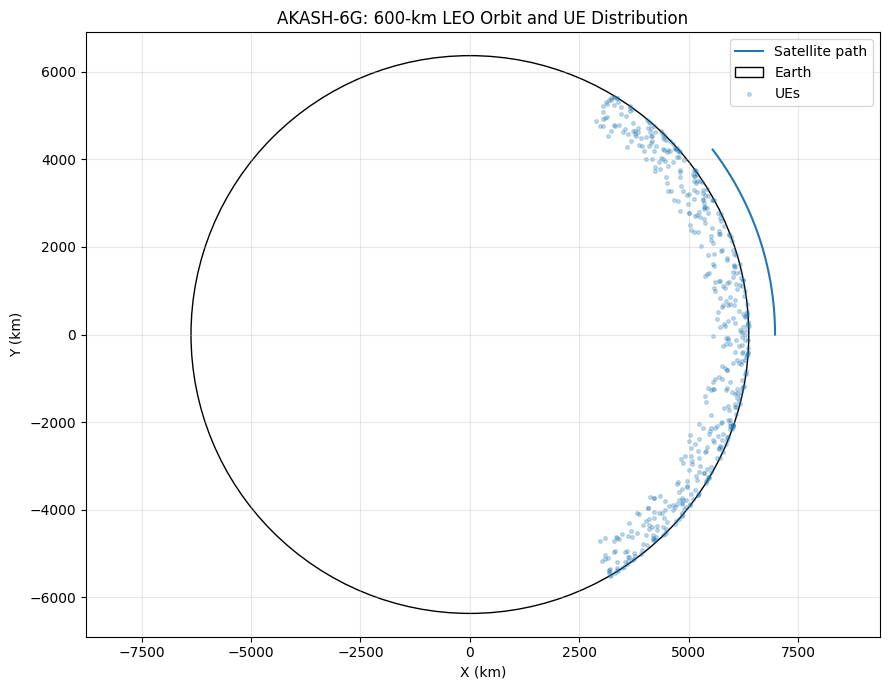

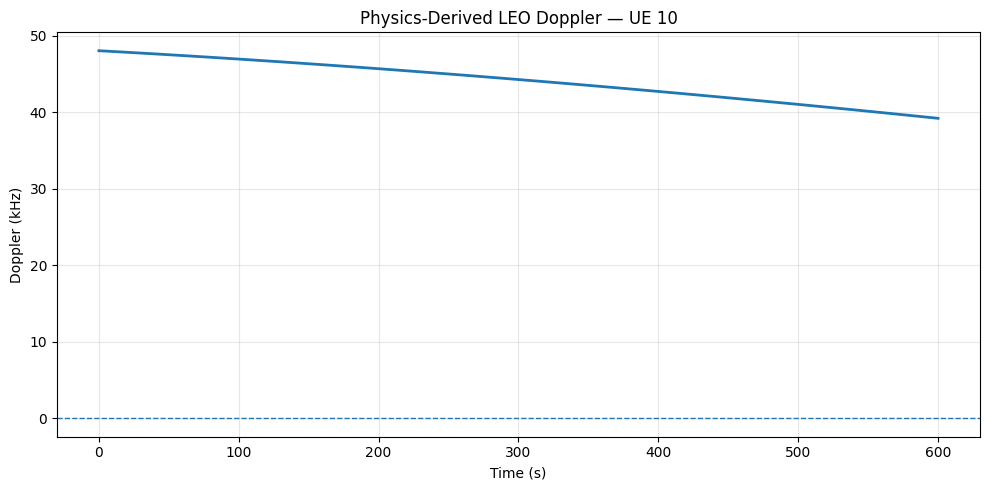

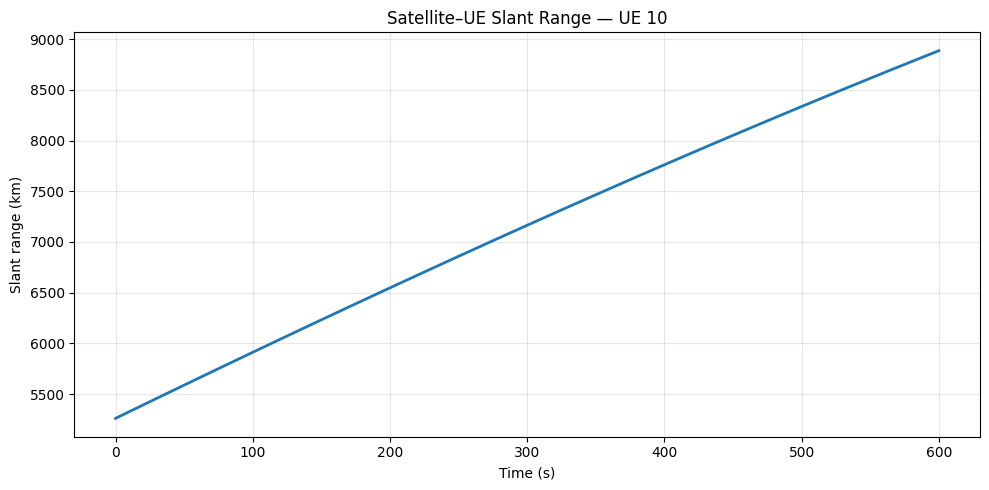

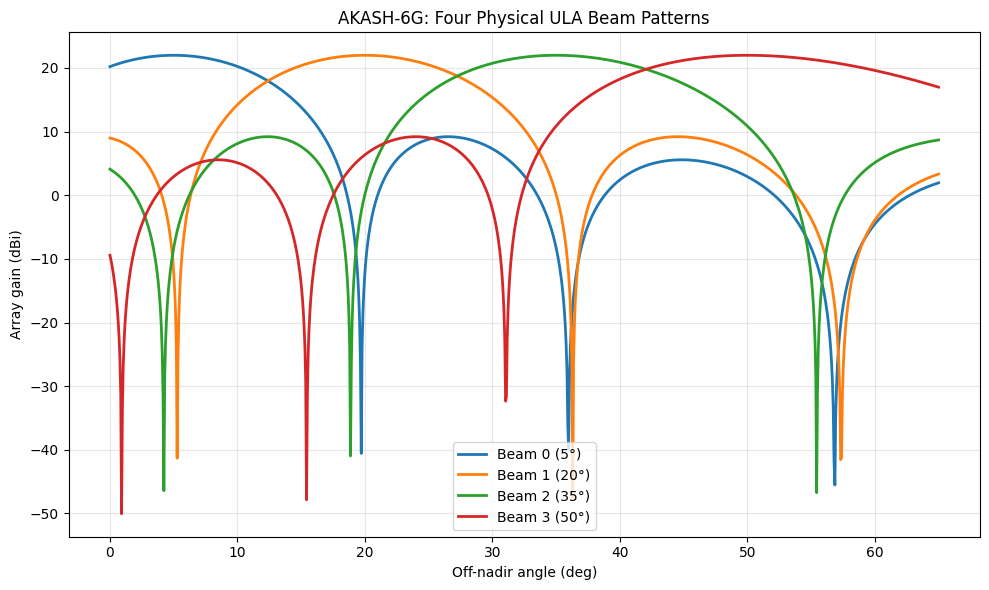

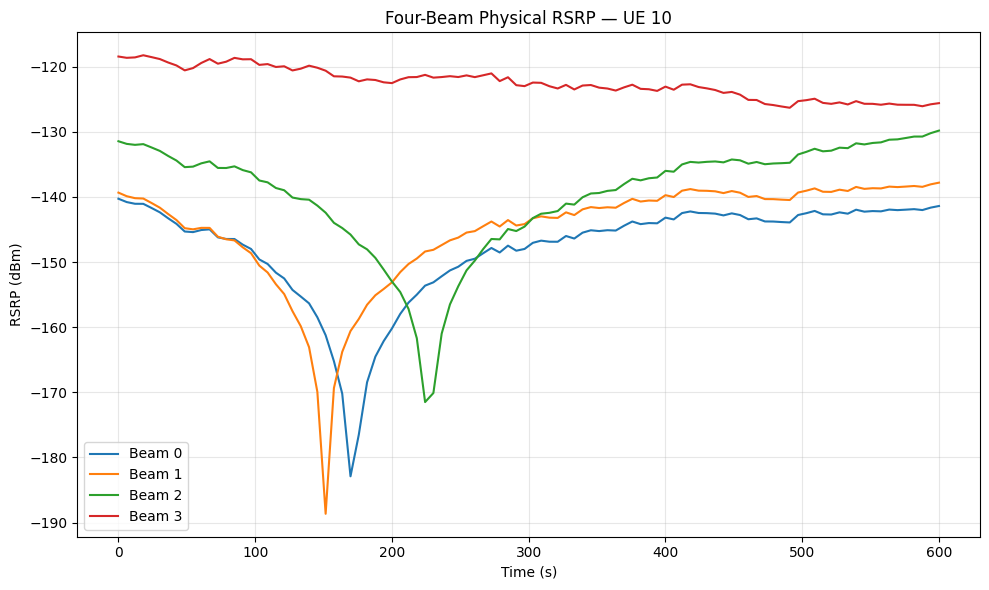

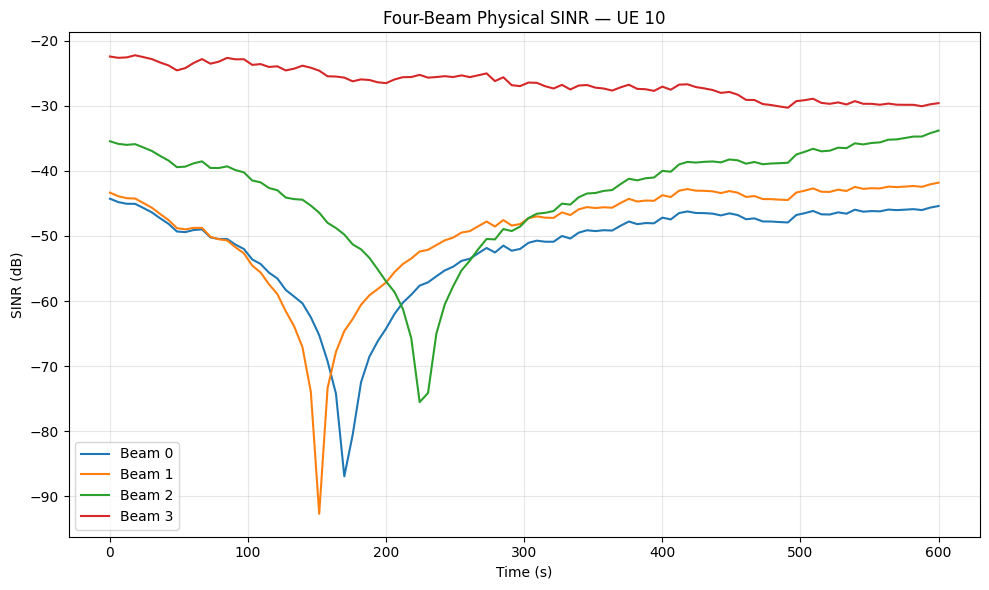


FILES CREATED
/content/AKASH6G_Physical_Beamforming_50000.xlsx
/content/AKASH6G_Physical_Beamforming_50000.csv
Six PNG figures were also saved.

For Colab, optionally run:
from google.colab import files
files.download('AKASH6G_Physical_Beamforming_50000.xlsx')
files.download('AKASH6G_Physical_Beamforming_50000.csv')


In [7]:
import math, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

# ---------------- PHYSICAL CONFIGURATION ----------------
EARTH_R_KM = 6371.0
ALT_KM = 600.0
ORBIT_R_KM = EARTH_R_KM + ALT_KM
MU_KM3_S2 = 398600.4418
C = 299792458.0

FC_HZ = 2.185e9
BW_HZ = 20e6
NF_DB = 5.0
PT_DBM = 35.0
GRX_DBI = 0.0
ARRAY_PEAK_DBI = 22.0

N_UE = 500
N_TIME = 100
TOTAL_TIME_S = 600.0
MIN_ELEV_DEG = 5.0

# 8-element ULA, lambda/2 spacing, elevation-plane model
N_ELEM = 8
D_LAMBDA = 0.5
BEAM_CENTERS_DEG = np.array([5., 20., 35., 50.])

# Correlated stochastic fading. NOT a full 3GPP TDL-A implementation.
FADING_STD_DB = 1.5
FADING_AR = 0.96
INTERFERENCE_FACTOR = 0.05

V_ORBIT_KM_S = math.sqrt(MU_KM3_S2 / ORBIT_R_KM)
OMEGA_RAD_S = V_ORBIT_KM_S / ORBIT_R_KM
PERIOD_S = 2 * math.pi / OMEGA_RAD_S
LAMBDA_M = C / FC_HZ
D_M = D_LAMBDA * LAMBDA_M
NOISE_DBM = -174 + 10 * math.log10(BW_HZ) + NF_DB

print("AKASH-6G PHASE 1 — PHYSICAL LEO + BEAMFORMING")
print(f"Records: {N_UE*N_TIME:,} | UEs: {N_UE} | samples/UE: {N_TIME}")
print(f"Orbit: {ALT_KM:.0f} km | velocity: {V_ORBIT_KM_S:.4f} km/s")
print(f"Angular rate: {OMEGA_RAD_S:.7f} rad/s | period: {PERIOD_S/60:.2f} min")
print(f"Carrier: {FC_HZ/1e9:.3f} GHz | wavelength: {LAMBDA_M:.4f} m")
print(f"ULA: {N_ELEM} elements, lambda/2 spacing | beams: {BEAM_CENTERS_DEG.tolist()}")

def ecef(lat, lon, r=EARTH_R_KM):
    lat, lon = np.deg2rad(lat), np.deg2rad(lon)
    return np.column_stack((r*np.cos(lat)*np.cos(lon),
                            r*np.cos(lat)*np.sin(lon),
                            r*np.sin(lat)))

def fspl_db(d_km):
    d_m = np.maximum(d_km, 1e-6)*1000
    return 20*np.log10(4*np.pi*d_m*FC_HZ/C)

def ula_gain_db(theta_deg, center_deg):
    # theta is off-nadir angle; normalized ULA array factor.
    th = np.deg2rad(theta_deg)
    th0 = np.deg2rad(center_deg)
    n = np.arange(N_ELEM)
    psi = 2*np.pi*D_LAMBDA*(np.sin(th)-np.sin(th0))
    af = np.sum(np.exp(1j*n*psi))/N_ELEM
    return 10*np.log10(max(abs(af)**2, 1e-12))

def ar_fading(n):
    x = np.zeros(n)
    x[0] = rng.normal(0, FADING_STD_DB)
    s = FADING_STD_DB*np.sqrt(1-FADING_AR**2)
    for i in range(1,n):
        x[i] = FADING_AR*x[i-1] + rng.normal(0,s)
    return x

# ---------------- FIXED TERRESTRIAL UEs ----------------
lat = rng.uniform(-30, 30, N_UE)
lon = rng.uniform(-60, 60, N_UE)
ue_xyz = ecef(lat, lon)

# ---------------- PHYSICAL CIRCULAR LEO ----------------
t = np.linspace(0, TOTAL_TIME_S, N_TIME)
ang = OMEGA_RAD_S*t
sx = ORBIT_R_KM*np.cos(ang)
sy = ORBIT_R_KM*np.sin(ang)
sz = np.zeros(N_TIME)
svx = -ORBIT_R_KM*OMEGA_RAD_S*np.sin(ang)
svy =  ORBIT_R_KM*OMEGA_RAD_S*np.cos(ang)
svz = np.zeros(N_TIME)

rows = []
for uid in range(N_UE):
    fading = ar_fading(N_TIME)
    u = ue_xyz[uid]
    up = u/np.linalg.norm(u)
    for k, tk in enumerate(t):
        s = np.array([sx[k], sy[k], sz[k]])
        v = np.array([svx[k], svy[k], svz[k]])
        los = u-s
        dist = np.linalg.norm(los)
        lh = los/dist

        # Positive range rate = satellite moving away.
        radial_km_s = float(np.dot(v, lh))
        doppler_hz = -(FC_HZ/C)*radial_km_s*1000

        elev = np.rad2deg(np.arcsin(np.clip(np.dot(lh, up), -1, 1)))
        visible = int(elev >= MIN_ELEV_DEG)

        nadir = -s/np.linalg.norm(s)
        off_nadir = np.rad2deg(np.arccos(np.clip(np.dot(lh,nadir),-1,1)))
        az = np.rad2deg(np.arctan2(lh[1],lh[0]))

        pl = fspl_db(dist)
        gains = np.array([ARRAY_PEAK_DBI + ula_gain_db(off_nadir,b)
                          for b in BEAM_CENTERS_DEG])

        if visible:
            rsrp = PT_DBM + GRX_DBI + gains - pl + fading[k]
            mw = 10**(rsrp/10)
            noise_mw = 10**(NOISE_DBM/10)
            interf = INTERFERENCE_FACTOR*(mw.sum()-mw)
            sinr = 10*np.log10(np.maximum(mw/(interf+noise_mw),1e-15))
            opt = int(np.argmax(sinr))
            se = np.log2(1+10**(sinr[opt]/10))
            thr = BW_HZ*se*0.82/1e6
            margin = np.sort(sinr)[-1]-np.sort(sinr)[-2]
        else:
            rsrp = np.full(4,np.nan); sinr = np.full(4,np.nan)
            opt, thr, margin = -1, np.nan, np.nan

        rows.append([tk,tk*1000,uid+1,lat[uid],lon[uid],
                     s[0],s[1],s[2],v[0],v[1],v[2],
                     V_ORBIT_KM_S,OMEGA_RAD_S,dist,elev,off_nadir,az,visible,
                     radial_km_s,doppler_hz,pl,fading[k],
                     *(off_nadir-BEAM_CENTERS_DEG),
                     *gains,*rsrp,*sinr,opt,
                     np.nan if opt<0 else sinr[opt],margin,thr])

cols = [
"Time_s","Time_ms","UE_ID","UE_Latitude_deg","UE_Longitude_deg",
"Satellite_X_km","Satellite_Y_km","Satellite_Z_km",
"Satellite_Vx_km_s","Satellite_Vy_km_s","Satellite_Vz_km_s",
"Orbital_Speed_km_s","Orbital_Angular_Speed_rad_s",
"Slant_Range_km","Elevation_Angle_deg","Off_Nadir_Angle_deg",
"Satellite_Look_Azimuth_deg","Visible","Radial_Velocity_km_s","Doppler_Hz",
"Free_Space_Path_Loss_dB","Correlated_Fading_dB",
"Beam0_Angular_Error_deg","Beam1_Angular_Error_deg",
"Beam2_Angular_Error_deg","Beam3_Angular_Error_deg",
"beam0_Array_Gain_dBi","beam1_Array_Gain_dBi",
"beam2_Array_Gain_dBi","beam3_Array_Gain_dBi",
"beam0_RSRP_dBm","beam1_RSRP_dBm","beam2_RSRP_dBm","beam3_RSRP_dBm",
"beam0_SINR_dB","beam1_SINR_dB","beam2_SINR_dB","beam3_SINR_dB",
"Optimal_Beam_Label","Best_SINR_dB","Beam_Margin_dB",
"Optimal_Throughput_Mbps"]
df = pd.DataFrame(rows,columns=cols)

# Doppler rate: Hz/s -> kHz/ms
df["Doppler_Rate_Hz_per_s"] = df.groupby("UE_ID")["Doppler_Hz"].transform(
    lambda x: np.gradient(x.to_numpy(), t))
df["Doppler_Rate_kHz_per_ms"] = df["Doppler_Rate_Hz_per_s"]/1e6

# Current beam = strongest instantaneous RSRP
rcols=[f"beam{i}_RSRP_dBm" for i in range(4)]
df["Current_Beam"]=df[rcols].idxmax(axis=1).str.extract(r"(\d)").astype("Int64")
df["Beam_Switch"]=df.groupby("UE_ID")["Current_Beam"].transform(
    lambda x:x.ne(x.shift()).fillna(False).astype(int))
df.loc[df.groupby("UE_ID").cumcount()==0,"Beam_Switch"]=0

# Approx. +200 ms target
dt=t[1]-t[0]
offset=max(1,int(round(.200/dt)))
df["Prediction_Horizon_ms"]=offset*dt*1000
df["Future_Optimal_Beam_200ms"]=df.groupby("UE_ID")["Optimal_Beam_Label"].shift(-offset).astype("Int64")
df["Future_Target_Available"]=df["Future_Optimal_Beam_200ms"].notna().astype(int)

# ---------------- VALIDATION ----------------
assert len(df)==50000
assert abs(df["Orbital_Speed_km_s"].iloc[0]-V_ORBIT_KM_S)<1e-12
assert np.isfinite(df["Doppler_Hz"]).all()
print("\nValidation passed.")
print("Visible records:", int(df.Visible.sum()))
print("Doppler range: %.2f to %.2f kHz" % (df.Doppler_Hz.min()/1000,df.Doppler_Hz.max()/1000))
v=df[df.Visible==1]
print("Elevation range: %.2f to %.2f deg" % (v.Elevation_Angle_deg.min(),v.Elevation_Angle_deg.max()))
print("Best SINR range: %.2f to %.2f dB" % (v.Best_SINR_dB.min(),v.Best_SINR_dB.max()))
print("Optimal beam (%):")
print(v.Optimal_Beam_Label.value_counts(normalize=True).sort_index().mul(100).round(2))

# ---------------- FIGURES ----------------
plot_ue=int(v.UE_ID.value_counts().idxmax())
p=df[df.UE_ID==plot_ue]

plt.figure(figsize=(9,7))
plt.plot(sx,sy,label="Satellite path")
plt.gca().add_patch(plt.Circle((0,0),EARTH_R_KM,fill=False,label="Earth"))
plt.scatter(ue_xyz[:,0],ue_xyz[:,1],s=7,alpha=.25,label="UEs")
plt.xlabel("X (km)"); plt.ylabel("Y (km)")
plt.title("AKASH-6G: 600-km LEO Orbit and UE Distribution")
plt.axis("equal"); plt.grid(alpha=.3); plt.legend()
plt.tight_layout(); plt.savefig("fig1_leo_orbit_ues.png",dpi=300); plt.show()

plt.figure(figsize=(10,5))
plt.plot(p.Time_s,p.Doppler_Hz/1000,lw=2)
plt.axhline(0,ls="--",lw=1)
plt.xlabel("Time (s)"); plt.ylabel("Doppler (kHz)")
plt.title(f"Physics-Derived LEO Doppler — UE {plot_ue}")
plt.grid(alpha=.3); plt.tight_layout()
plt.savefig("fig2_doppler.png",dpi=300); plt.show()

plt.figure(figsize=(10,5))
plt.plot(p.Time_s,p.Slant_Range_km,lw=2)
plt.xlabel("Time (s)"); plt.ylabel("Slant range (km)")
plt.title(f"Satellite–UE Slant Range — UE {plot_ue}") # Restored the complete title string
plt.grid(alpha=.3); plt.tight_layout()
plt.savefig("fig3_slant_range.png",dpi=300); plt.show()

angles=np.linspace(0,65,1000)
plt.figure(figsize=(10,6))
for b,c0 in enumerate(BEAM_CENTERS_DEG):
    g=np.array([ARRAY_PEAK_DBI+ula_gain_db(a,c0) for a in angles])
    plt.plot(angles,g,lw=2,label=f"Beam {b} ({c0:.0f}°)")
plt.xlabel("Off-nadir angle (deg)"); plt.ylabel("Array gain (dBi)")
plt.title("AKASH-6G: Four Physical ULA Beam Patterns")
plt.grid(alpha=.3); plt.legend(); plt.tight_layout()
plt.savefig("fig4_four_beam_patterns.png",dpi=300); plt.show()

plt.figure(figsize=(10,6))
for b in range(4): plt.plot(p.Time_s,p[f"beam{b}_RSRP_dBm"],label=f"Beam {b}")
plt.xlabel("Time (s)"); plt.ylabel("RSRP (dBm)")
plt.title(f"Four-Beam Physical RSRP — UE {plot_ue}")
plt.grid(alpha=.3); plt.legend(); plt.tight_layout()
plt.savefig("fig5_four_beam_rsrp.png",dpi=300); plt.show()

plt.figure(figsize=(10,6))
for b in range(4): plt.plot(p.Time_s,p[f"beam{b}_SINR_dB"],label=f"Beam {b}")
plt.xlabel("Time (s)"); plt.ylabel("SINR (dB)")
plt.title(f"Four-Beam Physical SINR — UE {plot_ue}")
plt.grid(alpha=.3); plt.legend(); plt.tight_layout()
plt.savefig("fig6_four_beam_sinr.png",dpi=300); plt.show()

# ---------------- DQN STATE ----------------
dqn_cols=["Time_ms","UE_ID","Doppler_Hz","Doppler_Rate_kHz_per_ms",
"Slant_Range_km","Elevation_Angle_deg","Off_Nadir_Angle_deg",
"beam0_RSRP_dBm","beam1_RSRP_dBm","beam2_RSRP_dBm","beam3_RSRP_dBm",
"beam0_SINR_dB","beam1_SINR_dB","beam2_SINR_dB","beam3_SINR_dB",
"Current_Beam","Optimal_Beam_Label","Future_Optimal_Beam_200ms",
"Prediction_Horizon_ms","Future_Target_Available","Beam_Switch"]
dqn=df[df.Visible==1][dqn_cols].copy()

# ---------------- EXPORT ----------------
csv_name="AKASH6G_Physical_Beamforming_50000.csv"
xlsx_name="AKASH6G_Physical_Beamforming_50000.xlsx"
df.to_csv(csv_name,index=False)

params=pd.DataFrame({
"Parameter":["Earth radius km","Altitude km","Orbital velocity km/s",
"Angular velocity rad/s","Orbital period min","Carrier GHz","Bandwidth MHz",
"Noise figure dB","TX power dBm","ULA elements","Spacing lambda",
"Wavelength m","Beam centers deg","Interference factor","Min elevation deg",
"Fading std dB","Fading AR","Random seed"],
"Value":[EARTH_R_KM,ALT_KM,V_ORBIT_KM_S,OMEGA_RAD_S,PERIOD_S/60,
FC_HZ/1e9,BW_HZ/1e6,NF_DB,PT_DBM,N_ELEM,D_LAMBDA,LAMBDA_M,
str(BEAM_CENTERS_DEG.tolist()),INTERFERENCE_FACTOR,MIN_ELEV_DEG,
FADING_STD_DB,FADING_AR,SEED]})

audit=pd.DataFrame({
"Check":["Row count","UE count","Finite Doppler","Physical orbital speed",
"8-element ULA","lambda/2 spacing","Four beam patterns","Linear-domain SINR"],
"Result":[len(df)==50000,df.UE_ID.nunique()==500,np.isfinite(df.Doppler_Hz).all(),
True,N_ELEM==8,abs(D_LAMBDA-.5)<1e-12,True,True]})

with pd.ExcelWriter(xlsx_name,engine="openpyxl") as w:
    df.to_excel(w,sheet_name="all_data_physical",index=False)
    dqn.to_excel(w,sheet_name="DQN_state_physical",index=False)
    df[df.Visible==1].to_excel(w,sheet_name="visible_data",index=False)
    for b in range(4):
        df[df.Current_Beam==b].to_excel(w,sheet_name=f"beam{b}_physical",index=False)
    params.to_excel(w,sheet_name="parameters",index=False)
    audit.to_excel(w,sheet_name="physics_audit",index=False)

print("\nFILES CREATED")
print(os.path.abspath(xlsx_name))
print(os.path.abspath(csv_name))
print("Six PNG figures were also saved.")
print("\nFor Colab, optionally run:")
print("from google.colab import files")
print(f"files.download('{xlsx_name}')")
print(f"files.download('{csv_name}')")


### Preparing the dataset for beam prediction

The `dqn` DataFrame contains all the necessary features and target variables for predicting the future optimal beam. The goal will be to predict `Future_Optimal_Beam_200ms` based on the other available features at the current time step. This is a classification problem.

In [8]:
from sklearn.model_selection import train_test_split

# Drop rows where 'Future_Optimal_Beam_200ms' is NaN (where a future target is not available)
dqn_cleaned = dqn.dropna(subset=['Future_Optimal_Beam_200ms']).copy()

# Define features (X) and target (y)
# For features, we'll exclude the current optimal beam, the future optimal beam, and identifiers.
# We'll use the 'Optimal_Beam_Label' as a feature, assuming the current beam is known.
X = dqn_cleaned.drop(columns=[
    "UE_ID", "Optimal_Beam_Label", "Future_Optimal_Beam_200ms",
    "Prediction_Horizon_ms", "Future_Target_Available", "Time_ms"
])
y = dqn_cleaned['Future_Optimal_Beam_200ms'].astype(int)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f"Original DQN data shape: {dqn.shape}")
print(f"Cleaned DQN data shape: {dqn_cleaned.shape}")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

display(X_train.head())

Original DQN data shape: (31630, 21)
Cleaned DQN data shape: (31307, 21)
Training features shape: (25045, 15)
Testing features shape: (6262, 15)
Training target shape: (25045,)
Testing target shape: (6262,)


,Doppler_Hz,Doppler_Rate_kHz_per_ms,Slant_Range_km,Elevation_Angle_deg,Off_Nadir_Angle_deg,beam0_RSRP_dBm,beam1_RSRP_dBm,beam2_RSRP_dBm,beam3_RSRP_dBm,beam0_SINR_dB,beam1_SINR_dB,beam2_SINR_dB,beam3_SINR_dB,Current_Beam,Beam_Switch
14233,38096.559708,-8.340132e-06,7582.439184,30.811694,51.714477,-141.366447,-137.872727,-134.974027,-120.111733,-45.377629,-41.883901,-38.985188,-24.122081,3,0
23779,43378.500110,-6.697838e-06,6220.268067,22.778492,57.421071,-158.241249,-174.697246,-140.424441,-118.977345,-62.252648,-78.708645,-44.435833,-22.987653,3,0
38578,36854.465665,9.042273e-06,5789.384644,20.232859,59.040928,-148.419949,-148.522702,-137.430057,-120.984432,-52.430953,-52.533707,-41.441047,-24.994750,3,0
30406,41730.069657,3.861335e-07,5740.072115,19.939885,59.220154,-146.726064,-146.641209,-136.041156,-119.998796,-50.737250,-50.652395,-40.052323,-24.009121,3,0
43833,-44924.684175,5.631638e-06,4347.288598,11.341819,63.647667,-139.588948,-138.272404,-132.331393,-122.728334,-43.599772,-42.283224,-36.342175,-26.738707,3,0
